This notebook analyzes defect data from a manufacturing process to identify patterns, key variables, and potential root causes.

Objective:
- Understand defect distribution
- Identify key process variables
- Detect abnormal behavior patterns

In [2]:
# Dataset download

import os
os.makedirs("data/raw", exist_ok=True)
!kaggle datasets download -d uciml/faulty-steel-plates -p data/raw --unzip

HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDatasetMetadata (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))


In [3]:
# Library import and data reading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.set_palette("crest")

df = pd.read_csv("data/raw/faults.csv")

In [4]:
# Data overview

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

In [5]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


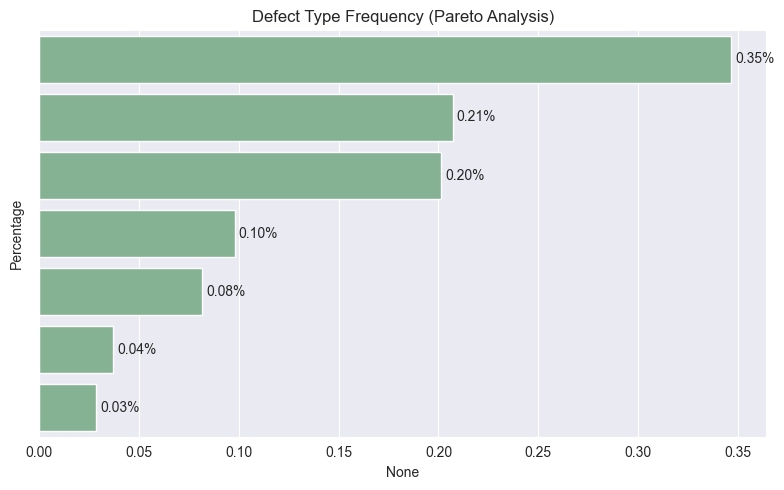

In [25]:
# Measure defect proportion in the dataset
defect_cols_names = df.columns[-7:]
defect_cols = df[defect_cols_names]
defect_count = defect_cols.sum().sort_values(ascending=False)
defect_distribution = defect_count/ defect_count.sum()

# Pareto chart
plt.figure(figsize=(8,5))
ax = sns.barplot(y=defect_distribution.index, x=defect_distribution)

# Add percentage labels inside the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)
    
# Remove the default y-axis label and tick labels
plt.title("Defect Type Frequency (Pareto Analysis)")
ax.set_ylabel('Percentage')
ax.set_yticklabels([])
plt.tight_layout()
plt.show()




###  Dataset Insight

- The dataset has 27 feature columns and  and 7 defect columns
- No missing values are observed in the dataset
- All observations in the dataset contain at least one defect, indicating that this dataset represents defective production scenarios only.
- The most frequent defect types are:

  - Other_Faults — 35%
  - Bumps — 21%
  - K_Scatch — 20%


### Engineering Interpretation

- Instead of a binary quality problem (defect vs no defect), this is a defect classification and prioritization problem.
- The presence of multiple defect types suggests:
  - Different root causes and failure mechanisms
  - Potential segmentation of the process into distinct failure modes


Modify to look at distributions per defect type

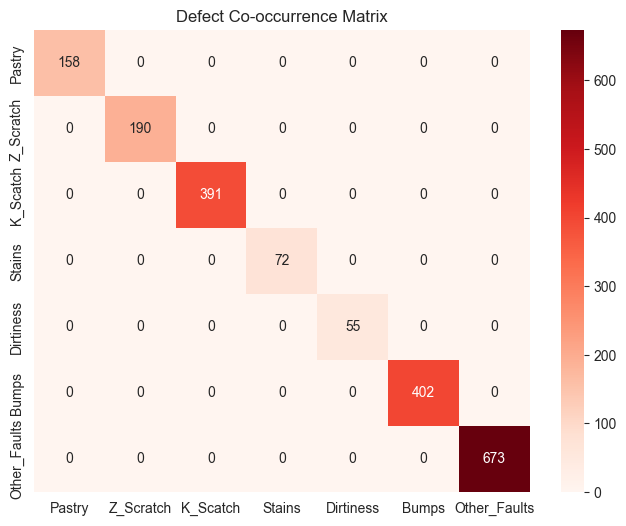

In [26]:
import seaborn as sns

co_occurrence = df[defect_cols_names].T.dot(df[defect_cols_names])

plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, annot=True, fmt=".0f", cmap="Reds")
plt.title("Defect Co-occurrence Matrix")
plt.show()

### Engineering Interpretation

- There is no co-occurence of defects, this means each entry corresponds to only one defect

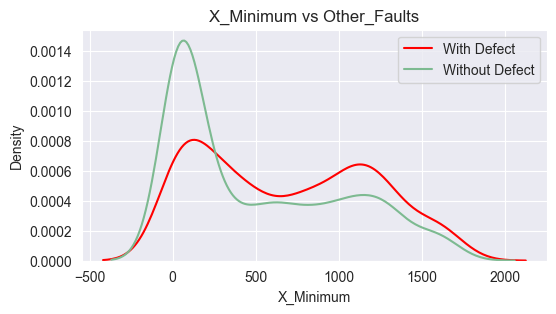

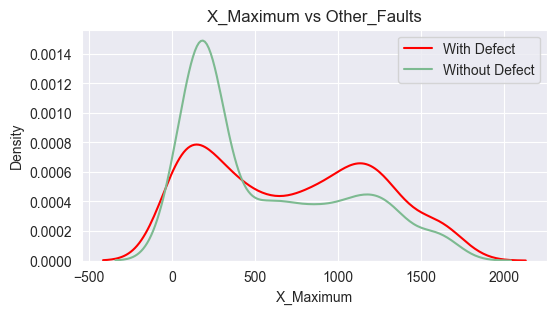

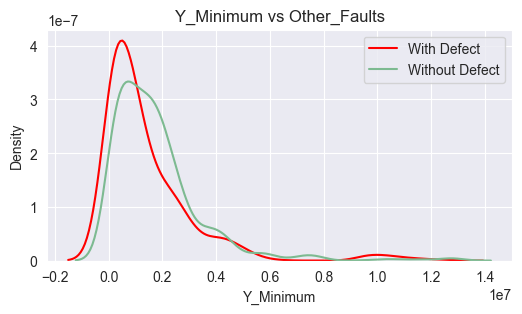

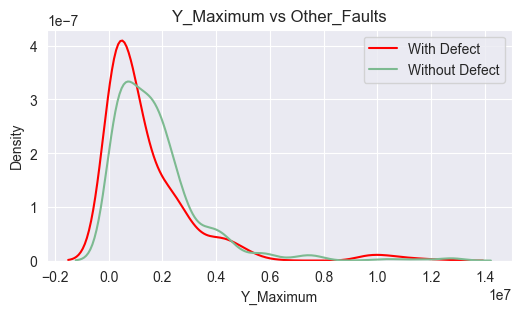

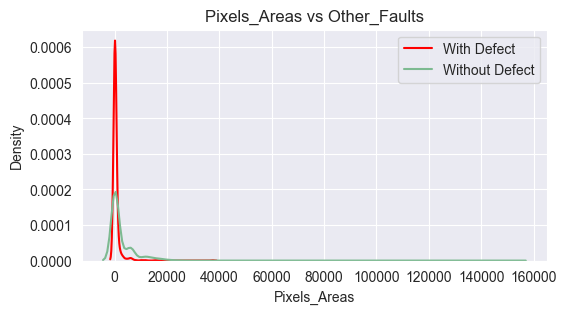

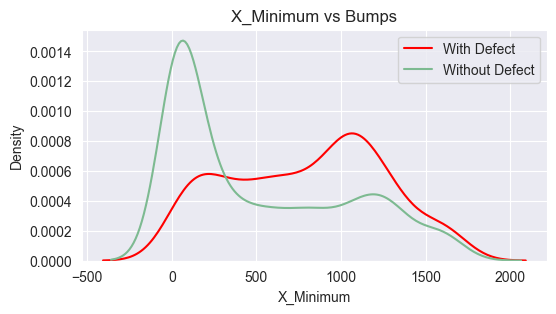

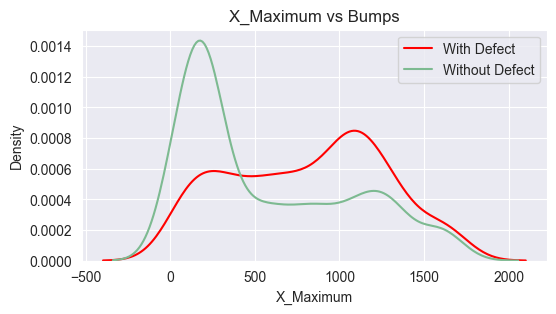

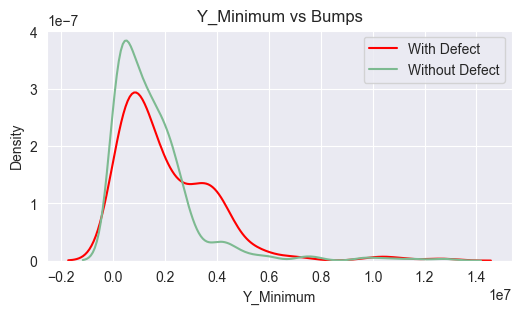

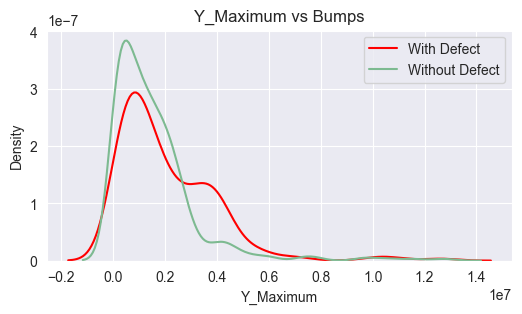

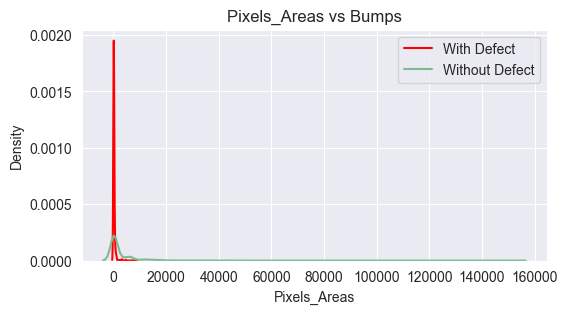

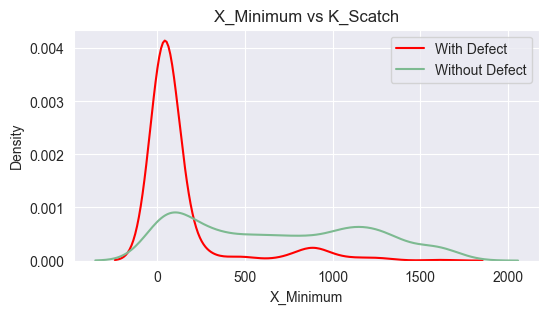

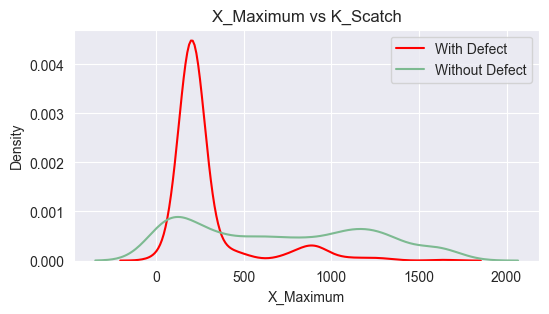

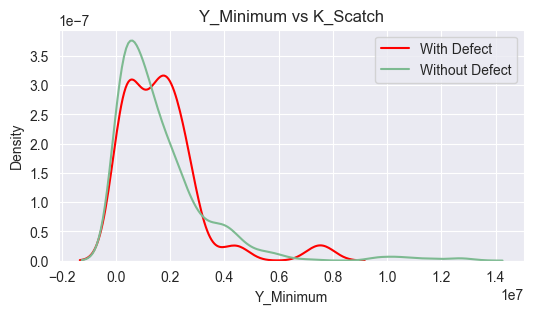

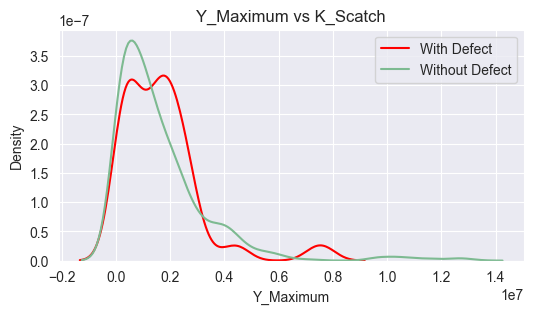

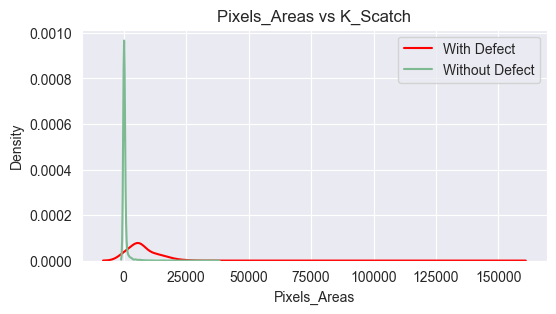

In [29]:
defect_counts = df[defect_cols_names].sum().sort_values(ascending=False)

top_defects = defect_counts.head(3).index

key_vars = df.select_dtypes(include="number").columns[:5]

for defect in top_defects:
    for col in key_vars:
        plt.figure(figsize=(6,3))
        sns.kdeplot(df[df[defect]==1][col], label="With Defect", color='r')
        sns.kdeplot(df[df[defect]==0][col], label="Without Defect")
        plt.title(f"{col} vs {defect}")
        plt.legend()
        plt.show()

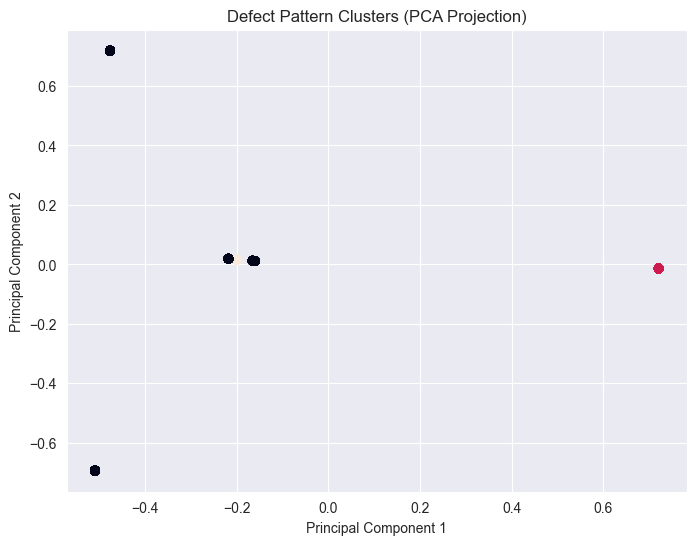

In [36]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["defect_cluster"] = kmeans.fit_predict(df[defect_cols_names])

# Reduce dimensions for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(df[defect_cols_names])

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(
    components[:, 0],
    components[:, 1],
    c=df["defect_cluster"],
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Defect Pattern Clusters (PCA Projection)")
plt.show()